In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import urllib.request

In [2]:
def load_gray_from_url(url):
    data = urllib.request.urlopen(url).read()
    arr = np.frombuffer(data, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    return img

In [3]:
def convolve2d_numpy(img, kernel):
    img = img.astype(np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)

    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2

    padded = np.pad(img, ((ph, ph), (pw, pw)), mode="reflect")
    h, w = img.shape
    out = np.zeros((h, w), dtype=np.float64)

    for y in range(h):
        for x in range(w):
            region = padded[y:y + kh, x:x + kw]
            out[y, x] = np.sum(region * kernel)

    return out

In [4]:
def sobel_numpy(img):
    gx_kernel = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float64)

    gy_kernel = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float64)

    gx = convolve2d_numpy(img, gx_kernel)
    gy = convolve2d_numpy(img, gy_kernel)

    magnitude = np.sqrt(gx ** 2 + gy ** 2)

    gx_vis = np.clip(np.abs(gx), 0, 255).astype(np.uint8)
    gy_vis = np.clip(np.abs(gy), 0, 255).astype(np.uint8)
    mag_vis = np.clip(magnitude, 0, 255).astype(np.uint8)

    return gx, gy, magnitude, gx_vis, gy_vis, mag_vis

In [5]:

url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/sudoku.png"
img = load_gray_from_url(url)

gx, gy, mag, gx_vis, gy_vis, mag_vis = sobel_numpy(img)

cv_gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
cv_gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
cv_mag = np.sqrt(cv_gx ** 2 + cv_gy ** 2)

cv_gx_vis = np.clip(np.abs(cv_gx), 0, 255).astype(np.uint8)
cv_gy_vis = np.clip(np.abs(cv_gy), 0, 255).astype(np.uint8)
cv_mag_vis = np.clip(cv_mag, 0, 255).astype(np.uint8)

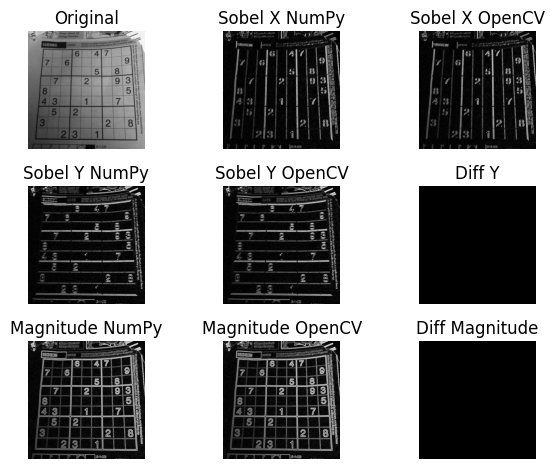

In [6]:
plt.subplot(3, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(gx_vis, cmap="gray")
plt.title("Sobel X NumPy")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(cv_gx_vis, cmap="gray")
plt.title("Sobel X OpenCV")
plt.axis("off")

plt.subplot(3, 3, 4)
plt.imshow(gy_vis, cmap="gray")
plt.title("Sobel Y NumPy")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(cv_gy_vis, cmap="gray")
plt.title("Sobel Y OpenCV")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(np.abs(gy_vis.astype(np.int16) - cv_gy_vis.astype(np.int16)).astype(np.uint8), cmap="gray")
plt.title("Diff Y")
plt.axis("off")

plt.subplot(3, 3, 7)
plt.imshow(mag_vis, cmap="gray")
plt.title("Magnitude NumPy")
plt.axis("off")

plt.subplot(3, 3, 8)
plt.imshow(cv_mag_vis, cmap="gray")
plt.title("Magnitude OpenCV")
plt.axis("off")

plt.subplot(3, 3, 9)
plt.imshow(np.abs(mag_vis.astype(np.int16) - cv_mag_vis.astype(np.int16)).astype(np.uint8), cmap="gray")
plt.title("Diff Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()